In [1]:
#import
from torch import nn,optim
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
from matplotlib import pyplot as plt
import os
import copy
import math

DEVICE= 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'current device: {DEVICE}')

current device: cpu


In [2]:
from google.colab import drive
drive.mount('/content/drive')
path='/content/drive/MyDrive/02_학업/02_연구 및 프로젝트/2512-2602_Dash 연구인턴/pytorch_practice'

Mounted at /content/drive


In [6]:
import torch

def load_workspace(filename):
    try:
        checkpoint_dir = os.path.join(path, 'checkpoints')
        output_dir = './saved_results'
        output_dir=os.path.join(checkpoint_dir,output_dir)
        # os.makedirs(output_dir, exist_ok=True)
        file_path_torch = os.path.join(output_dir, 'psa_results_torch.pt')

        # 1. 파일 읽기
        workspace = torch.load(file_path_torch,weights_only=False)

        # 2. 현재 세션의 전역 변수(globals)에 로드된 데이터 주입
        # globals()는 딕셔너리 형태이므로 update를 통해 한 번에 복구 가능합니다.
        globals().update(workspace)

        print(f"성공: {len(workspace)}개의 변수를 '{filename}'에서 복구했습니다.")

    except FileNotFoundError:
        print(f"오류: '{filename}' 파일을 찾을 수 없습니다.")
    except Exception as e:
        print(f"복구 중 알 수 없는 오류가 발생했습니다: {e}")

# 사용법
load_workspace('pruning_real_state.pth')

성공: 17개의 변수를 'pruning_real_state.pth'에서 복구했습니다.


In [ ]:
path='./'

In [3]:
checkpoint_dir = os.path.join(path, 'checkpoints')
print(os.listdir(checkpoint_dir))

['ckpt_ep1.pt', 'ckpt_ep2.pt', 'ckpt_ep3.pt', 'ckpt_ep5.pt', 'ckpt_ep10.pt', 'ckpt_ep15.pt', 'ckpt_ep20.pt', 'CNN_CIFAR10_final_weights.pth', 'best_model.pt']


In [4]:
root=os.path.join(path, 'data','test')
os.makedirs(root, exist_ok=True)
print(os.listdir(root))

['cifar-10-batches-py', 'cifar-10-python.tar.gz']


In [5]:
root=os.path.join(path, 'data','test')
os.makedirs(root, exist_ok=True)
BATCH_SIZE=128
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

full_train_DS = datasets.CIFAR10(root=root, train=True, download=True, transform=transform_train)
test_DS = datasets.CIFAR10(root=root, train=False, download=True, transform=transform_test)

train_size = 45000
val_size = 5000
train_DS, val_DS = random_split(full_train_DS, [train_size, val_size])

train_DL=torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = torch.utils.data.DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=False) # 검증용 추가
test_DL=torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data loaded: Train({len(train_DS)}), Val({len(val_DS)}), Test({len(test_DS)})")

Data loaded: Train(45000), Val(5000), Test(10000)


In [6]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        # self.conv1=nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        # self.maxPool=nn.MaxPool2d(kernel_size=2, stride=2)
        # self.conv2=nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv_layers=nn.Sequential( nn.Conv2d(3,64,3,padding=1),
                                        nn.BatchNorm2d(64),
                                        nn.ReLU(),
                                        nn.Conv2d(64,64,3,padding=1),
                                        nn.BatchNorm2d(64),
                                        nn.ReLU(),
                                        nn.MaxPool2d(2), # 32x32 -> 16x16

                                        nn.Conv2d(64,128,3,padding=1),
                                        nn.BatchNorm2d(128),
                                        nn.ReLU(),
                                        nn.Conv2d(128,128,3,padding=1),
                                        nn.BatchNorm2d(128),
                                        nn.ReLU(),
                                        nn.MaxPool2d(2), # 16x16 -> 8x8

                                        nn.Conv2d(128,256,3,padding=1),
                                        nn.BatchNorm2d(256),
                                        nn.ReLU(),
                                        nn.Conv2d(256,256,3,padding=1),
                                        nn.BatchNorm2d(256),
                                        nn.ReLU(),
                                        nn.Conv2d(256,256,3,padding=1),
                                        nn.BatchNorm2d(256),
                                        nn.ReLU(),
                                        nn.MaxPool2d(2)) # 8x8 -> 4x4
        self.flat=nn.Flatten(start_dim=1)
        self.fc_layers=nn.Sequential( nn.Linear(256*4*4,1024),
                                      nn.ReLU(),
                                      nn.Dropout(0.5),
                                      nn.Linear(1024,256),
                                      nn.ReLU(),
                                      nn.Dropout(0.5),
                                      nn.Linear(256,10))

    def forward(self, x):
        x=self.conv_layers(x)
        x=self.flat(x)
        x=self.fc_layers(x)
        return x

In [7]:
# 모델 불러오기 (아래처럼 모델 인스턴스 생성 후)
model = MyModel().to(DEVICE)
model.load_state_dict(torch.load(os.path.join(checkpoint_dir,'CNN_CIFAR10_final_weights.pth'), map_location=DEVICE))
model.eval()

# LR=0.001
# optimizer=optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
# 체크포인트 복원 예시 (옵티마이저까지 복원)
# ckpt = torch.load(os.path.join(checkpoint_dir, 'best_model.pt'), map_location=DEVICE)
# ckpt = torch.load(os.path.join(checkpoint_dir, 'ckpt_ep1.pt'), map_location=DEVICE)
# model.load_state_dict(ckpt['model_state_dict'])
# optimizer.load_state_dict(ckpt['optimizer_state_dict'])
# start_epoch = ckpt.get('epoch', 0)

MyModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [19]:
def Test(model, test_DL):
    model.eval() # test mode로 전환
    with torch.no_grad(): #model.eval과 같이 항상 해야 함
        rcorrect = 0
        num=len(test_DL.dataset)
        cnt=0
        for x_batch, y_batch in test_DL:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            # inference
            y_hat = model(x_batch)
            # corrects accumulation
            pred = y_hat.argmax(dim=1)
            corrects_b = torch.sum(pred == y_batch).item() # torch.eq(pred, y_batch).sum().item()
            rcorrect += corrects_b
            cnt+=1
            # print(f"Batch {cnt}/{len(test_DL)} processed")
        accuracy_e = rcorrect/len(test_DL.dataset)*100
    # print(f"Test accuracy: {rcorrect}/{len(test_DL.dataset)} ({accuracy_e:.1f} %)")
    return round(accuracy_e,1)

Test(model, test_DL)

86.3

In [ ]:
# ckpt = torch.load(os.path.join(checkpoint_dir, 'ckpt_ep20.pt'), map_location=DEVICE)
# model.load_state_dict(ckpt['model_state_dict'])
model.load_state_dict(torch.load(os.path.join(checkpoint_dir,'CNN_CIFAR10_final_weights.pth'), map_location=DEVICE))
Test(model, test_DL)

dict_keys(['training', '_parameters', '_buffers', '_non_persistent_buffers_set', '_backward_pre_hooks', '_backward_hooks', '_is_full_backward_hook', '_forward_hooks', '_forward_hooks_with_kwargs', '_forward_hooks_always_called', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_state_dict_hooks', '_state_dict_pre_hooks', '_load_state_dict_pre_hooks', '_load_state_dict_post_hooks', '_modules'])
dict_keys(['conv_layers', 'flat', 'fc_layers'])


In [ ]:
print(model.__dict__.keys())
# print(model.__dict__)
print(model.__dict__['_modules'].keys())

print(model.conv_layers)
print(len(model.conv_layers[3].weight))
print(model.conv_layers[3].weight.shape)

print(model.fc_layers)
print(len(model.fc_layers[6].weight))
print(model.fc_layers[6].weight.shape)


print(model.fc_layers[6].weight.data.shape[0])
# print(dir(model.fc_layers[6].weight))

Sequential(
  (0): Linear(in_features=4096, out_features=1024, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=1024, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=256, out_features=10, bias=True)
)
10
torch.Size([10, 256])


In [9]:
import copy
pruned_model_copy = copy.deepcopy(model)


In [16]:
weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0]]
layers=len(weight_param_list)
print(f"웨이트 파라미터 개수: {layers}")

target_name, original_param = weight_param_list[16]
print(f"Target Parameter Name: {target_name}")

weight_tensor=original_param.data.clone()
print(weight_tensor.shape)
l1_mag=torch.abs(weight_tensor)

val,idx= torch.sort(l1_mag.flatten())

pruning_percentage = 0.7
n_prune = int(weight_tensor.flatten().shape[0] * pruning_percentage)
print(f"pruning 비율: {pruning_percentage*100}%, pruning 개수: {n_prune}")

# with idx
pruning_mask_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
pruning_mask_flat[idx[:n_prune]]=0
pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)
# print(pruning_mask)
pruned_weight=weight_tensor*pruning_mask

#
pruned_params_dict = dict(pruned_model_copy.named_parameters())
with torch.no_grad():
    pruned_params_dict[target_name].copy_(pruned_weight)

# 결과 비교
Test(model, test_DL)
Test(pruned_model_copy, test_DL)

전체 파라미터 개수: 34
웨이트 파라미터 개수: 17
Target Parameter Name: fc_layers.6.weight
torch.Size([10, 256])
pruning 비율: 70.0%, pruning 개수: 1792
Test accuracy: 8630/10000 (86.3 %)
Test accuracy: 8550/10000 (85.5 %)


85.5

In [ ]:
weight_tensor = model.fc_layers[6].weight.data.clone()
l1_mag=torch.abs(weight_tensor)

val,idx= torch.sort(l1_mag.flatten())

pruning_percentage = 0.95
n_prune = int(weight_tensor.flatten().shape[0] * pruning_percentage)
print(n_prune)

# with val
pruning_mask1=(l1_mag>val[n_prune-1]).float()
print(pruning_mask1)
pruned_weight1=weight_tensor*pruning_mask1

# with idx
pruning_mask2_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
pruning_mask2_flat[idx[:n_prune]]=0
pruning_mask2=pruning_mask2_flat.reshape(l1_mag.shape)
print(pruning_mask2)
pruned_weight2=weight_tensor*pruning_mask2


# Print some statistics
print(torch.sum(weight_tensor == 0).item())
print(torch.sum(pruned_weight1 == 0).item())
print(torch.sum(pruned_weight2 == 0).item())

# pruning layer 적용
pruned_model_copy.fc_layers[6].weight.data=pruned_weight2

# check
print(model.fc_layers[6].weight)
print(pruned_model_copy.fc_layers[6].weight)

print(torch.sum(model.fc_layers[6].weight.data == 0).item())
print(torch.sum(pruned_model_copy.fc_layers[6].weight.data == 0).item())

In [ ]:
print("--- Comparing weights and biases between original model and pruned_model_copy ---")

# Get named parameters for both models
model_params = dict(model.named_parameters())
pruned_model_copy_params = dict(pruned_model_copy.named_parameters())

# Iterate through parameters of the original model
for name, param in model_params.items():
    if name in pruned_model_copy_params:
        pruned_param = pruned_model_copy_params[name]

        # Compare the tensors
        is_equal = torch.equal(param.data, pruned_param.data)

        # Print comparison result
        print(f"Parameter '{name}': {'Identical' if is_equal else 'DIFFERENT'}")
    else:
        print(f"Parameter '{name}' not found in pruned_model_copy (this should not happen in deepcopy).")

print("\nComparison complete.")


In [8]:
# Pruning Granularity,Pruning Criterion 를 주어지면
# 모든 layer, 모든 Pruning Ratio를 비교하는 함
# The process of Sensitivity Analysis
# def PSA(model, Granularity, Pruning_Criterion):
def PSA(model):
    weight_param_list = [p for p in model.named_parameters() if 'weight' in p[0]]
    layers=len(weight_param_list)
    org_acc=Test(model, test_DL)
    results = {}

    pruned_model = copy.deepcopy(model)
    params_dict = dict(pruned_model.named_parameters())

    for i in range(layers):
        target_name, original_param = weight_param_list[i]
        results[target_name]=[]
        weight_tensor=original_param.data.clone()

        # criterion
        l1_mag=torch.abs(weight_tensor)
        # granularity
        val,idx= torch.sort(l1_mag.flatten())

        # ratio: 0%~95%
        for j in range(20):
            ratio=j/20.0
            n_prune = int(weight_tensor.numel() * ratio)

            # pruning 마스크 생성
            pruning_mask_flat=torch.ones_like(l1_mag.flatten(), dtype=torch.float32)
            pruning_mask_flat[idx[:n_prune]]=0
            pruning_mask=pruning_mask_flat.reshape(l1_mag.shape)

            with torch.no_grad():
                # pruning weight 생성
                pruned_weight=weight_tensor*pruning_mask
                # pruning 적용
                params_dict[target_name].copy_(pruned_weight)

            acc = Test(pruned_model, test_DL)
            results[target_name].append({'ratio': ratio, 'acc': acc})

            print(f'Progress: {100*(i*20+j)/(layers*20.0):.2f}%')

        with torch.no_grad():
            # pruning 복구
            params_dict[target_name].copy_(weight_tensor)

    return results,org_acc


def plot_sensitivity(psa_results, org_acc):
    plt.figure(figsize=(12, 8))

    for layer_name, data in psa_results.items():
        ratios = [item['ratio'] for item in data]
        accs = [item['acc'] for item in data]

        plt.plot(ratios, accs, marker='o', markersize=4, label=layer_name, alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.xlabel('Pruning Ratio (Sparsity)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)

    plt.tight_layout()
    plt.show()

In [21]:
results,org_acc=PSA(model)

Progress: 0.00%
Progress: 0.29%
Progress: 0.59%
Progress: 0.88%
Progress: 1.18%
Progress: 1.47%
Progress: 1.76%
Progress: 2.06%
Progress: 2.35%
Progress: 2.65%
Progress: 2.94%
Progress: 3.24%
Progress: 3.53%
Progress: 3.82%
Progress: 4.12%
Progress: 4.41%
Progress: 4.71%
Progress: 5.00%
Progress: 5.29%
Progress: 5.59%
Progress: 5.88%
Progress: 6.18%
Progress: 6.47%
Progress: 6.76%
Progress: 7.06%
Progress: 7.35%
Progress: 7.65%
Progress: 7.94%
Progress: 8.24%
Progress: 8.53%
Progress: 8.82%
Progress: 9.12%
Progress: 9.41%
Progress: 9.71%
Progress: 10.00%
Progress: 10.29%
Progress: 10.59%
Progress: 10.88%
Progress: 11.18%
Progress: 11.47%
Progress: 11.76%
Progress: 12.06%
Progress: 12.35%
Progress: 12.65%
Progress: 12.94%
Progress: 13.24%
Progress: 13.53%
Progress: 13.82%
Progress: 14.12%
Progress: 14.41%
Progress: 14.71%
Progress: 15.00%
Progress: 15.29%
Progress: 15.59%
Progress: 15.88%
Progress: 16.18%
Progress: 16.47%
Progress: 16.76%
Progress: 17.06%
Progress: 17.35%
Progress: 17.6

In [27]:
import torch
import os

# 저장할 파일 경로 설정
output_dir = './saved_results'
output_dir=os.path.join(checkpoint_dir,output_dir)
os.makedirs(output_dir, exist_ok=True)
file_path_torch = os.path.join(output_dir, 'psa_results_torch.pt')

# 'results' 딕셔너리 저장
with open(file_path_torch, 'wb') as f:
    torch.save(results, f)
print(f"Results saved to {file_path_torch}")

# 저장된 'results' 딕셔너리 불러오기
with open(file_path_torch, 'rb') as f:
    loaded_results_torch = torch.load(f)
print(f"Results loaded from {file_path_torch}")

# 불러온 데이터 확인 (일부)
print("Loaded results (first layer): ", loaded_results_torch[list(loaded_results_torch.keys())[0]][:2])

Results saved to /content/drive/MyDrive/02_학업/02_연구 및 프로젝트/2512-2602_Dash 연구인턴/pytorch_practice/checkpoints/./saved_results/psa_results_torch.pt
Results loaded from /content/drive/MyDrive/02_학업/02_연구 및 프로젝트/2512-2602_Dash 연구인턴/pytorch_practice/checkpoints/./saved_results/psa_results_torch.pt
Loaded results (first layer):  [{'ratio': 0.0, 'acc': 86.3}, {'ratio': 0.05, 'acc': 86.4}]


In [9]:
plot_sensitivity(results, org_acc)

NameError: name 'results' is not defined

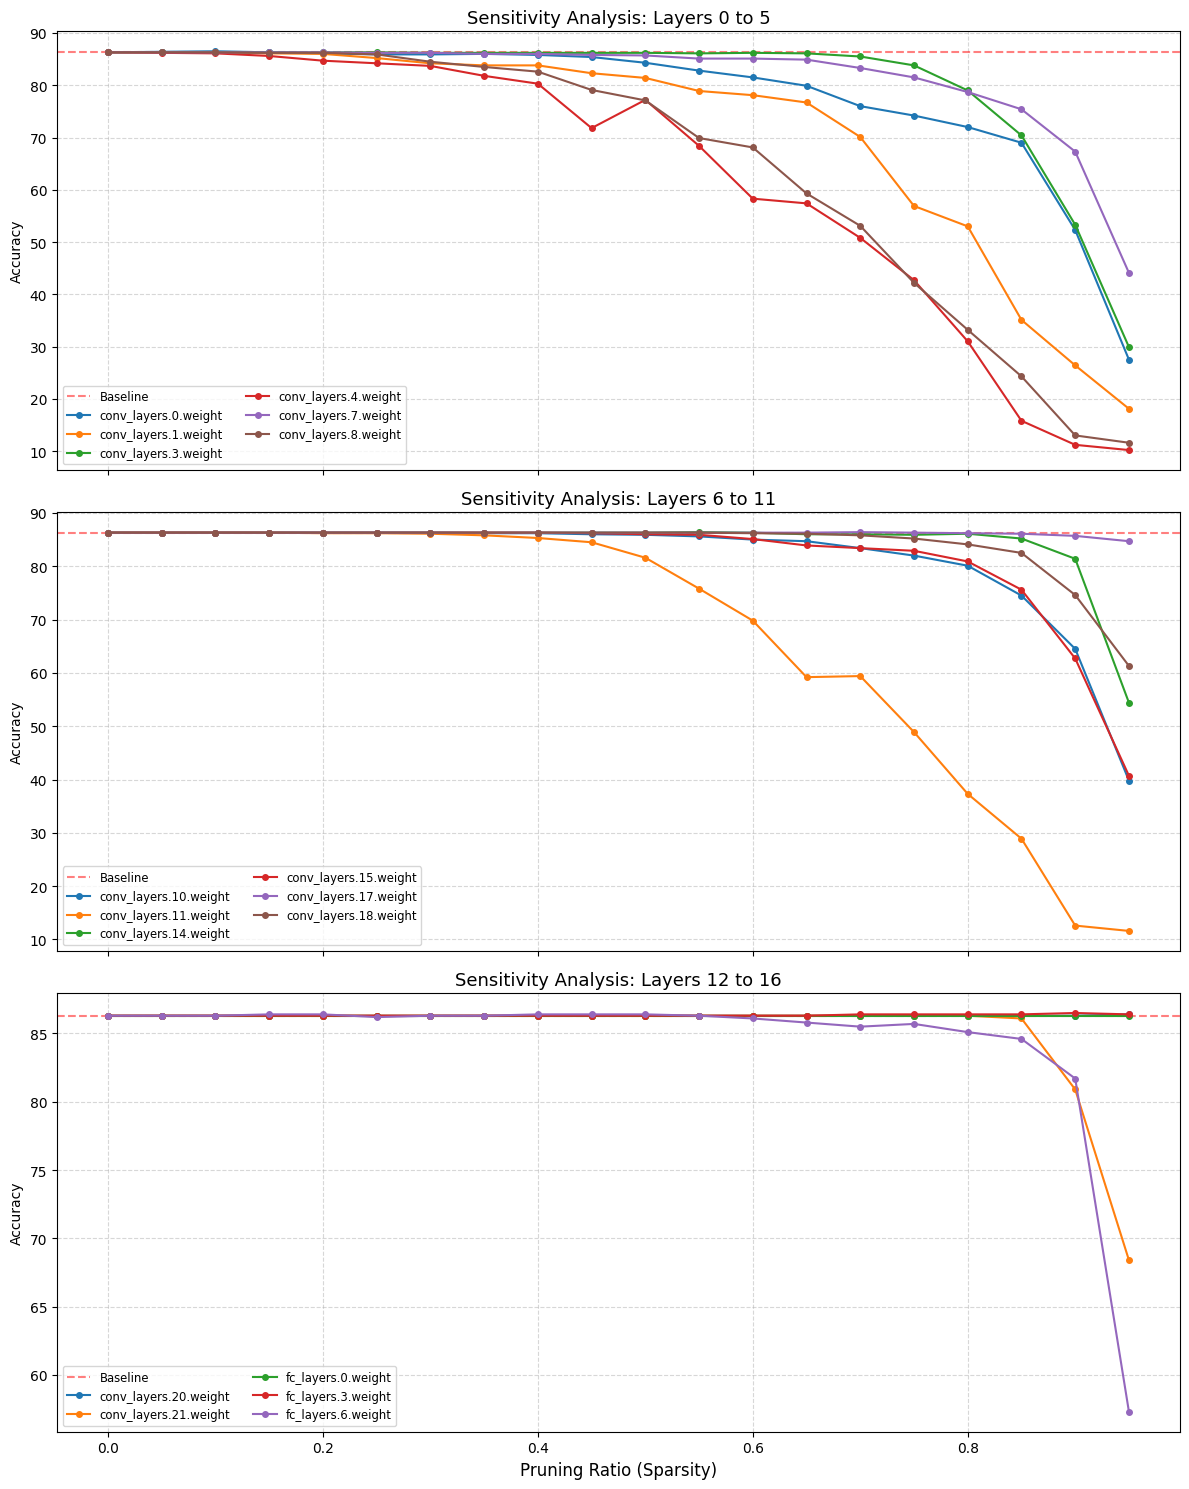

In [25]:
import math
def plot_sensitivity_subplots(psa_results, org_acc=None):
    layer_names = list(psa_results.keys())
    num_layers = len(layer_names)
    layers_per_plot = 6
    num_plots = math.ceil(num_layers / layers_per_plot)

    # 전체 Figure 크기 설정 (세로로 길게 배치)
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 5 * num_plots), sharex=True)

    # axes가 하나일 경우 리스트로 변환
    if num_plots == 1:
        axes = [axes]

    for i in range(num_plots):
        start_idx = i * layers_per_plot
        end_idx = min(start_idx + layers_per_plot, num_layers)

        ax = axes[i]

        # 원본 정확도 가이드라인 (입력되었을 경우만)
        if org_acc is not None:
            ax.axhline(y=org_acc, color='r', linestyle='--', alpha=0.5, label='Baseline')

        # 6개씩 레이어 플로팅
        for j in range(start_idx, end_idx):
            name = layer_names[j]
            data = psa_results[name]
            ratios = [item['ratio'] for item in data]
            accs = [item['acc'] for item in data]

            ax.plot(ratios, accs, marker='o', markersize=4, label=name)

        ax.set_title(f'Sensitivity Analysis: Layers {start_idx} to {end_idx-1}', fontsize=13)
        ax.set_ylabel('Accuracy')
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        ax.legend(loc='lower left', fontsize='small', ncol=2)

    axes[-1].set_xlabel('Pruning Ratio (Sparsity)', fontsize=12)

    plt.tight_layout()
    plt.show()

plot_sensitivity_subplots(results, org_acc)

In [30]:
def save_workspace(filename):
    # 시스템 변수, 모듈, 함수 등을 제외하고 순수 데이터 변수만 추출
    current_globals = globals().copy()
    excluded_types = (type(torch), type(len)) # 모듈과 내장 함수 제외

    output_dir = './saved_results'
    output_dir=os.path.join(checkpoint_dir,output_dir)
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, filename)

    workspace = {}
    for k, v in current_globals.items():
        # 언더바(_)로 시작하지 않고, 모듈/함수가 아닌 변수만 저장
        if not k.startswith('_') and not isinstance(v, excluded_types):
            try:
                # 실제로 저장이 가능한지 테스트 삼아 시도 (에러 방지)
                torch.save(v, 'temp.ptr')
                workspace[k] = v
            except:
                continue

    torch.save(workspace, file_path)
    print(f"총 {len(workspace)}개의 변수가 {filename}에 저장되었습니다.")

# 사용법
save_workspace('pruning_real_state.pth')

총 37개의 변수가 pruning_real_state.pth에 저장되었습니다.


In [ ]:
import torch

def load_workspace(filename):
    try:
        # 1. 파일 읽기
        workspace = torch.load(filename)

        # 2. 현재 세션의 전역 변수(globals)에 로드된 데이터 주입
        # globals()는 딕셔너리 형태이므로 update를 통해 한 번에 복구 가능합니다.
        globals().update(workspace)

        print(f"성공: {len(workspace)}개의 변수를 '{filename}'에서 복구했습니다.")

    except FileNotFoundError:
        print(f"오류: '{filename}' 파일을 찾을 수 없습니다.")
    except Exception as e:
        print(f"복구 중 알 수 없는 오류가 발생했습니다: {e}")

# 사용법
load_workspace('pruning_real_state.pth')